In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import xgboost as xgb
import lightgbm as lgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

## Cargar los datos

In [28]:
df = pd.read_csv('/content/drive/MyDrive/TABLA_FINAL_MODULAR.csv')

# Análisis inicial
print("Dimensiones del dataset:", df.shape)
print("\nPrimeras filas:")
print(df.head())
print("\nInformación de tipos de datos:")
print(df.info())
print("\nEstadísticas descriptivas:")
print(df.describe())

Dimensiones del dataset: (1195, 175)

Primeras filas:
  order_month product_category_name  demand  unique_products  unique_orders  \
0     2016-10             alimentos       1                1              1   
1     2016-10                 audio       2                2              2   
2     2016-10            automotivo       8                8              8   
3     2016-10                 bebes      11               10              9   
4     2016-10          beleza_saude      40               28             36   

   unique_customers  unique_sellers  total_sales   avg_price   price_std  ...  \
0                 1               1        79.90   79.900000    0.000000  ...   
1                 2               1       156.99   78.495000   75.667497  ...   
2                 8               8      1128.26  141.032500  173.996594  ...   
3                 9               6      1371.17  124.651818   99.291111  ...   
4                36              14      3439.25   85.981250   67.


## Verificar valores nulos

In [37]:
df.shape

(1195, 175)

In [31]:
print("\nValores nulos por columna:")
print(df.isnull().sum().sort_values(ascending=False).head(10))


Valores nulos por columna:
product_category_name    20
order_month               0
demand                    0
unique_products           0
unique_orders             0
unique_customers          0
unique_sellers            0
total_sales               0
avg_price                 0
price_std                 0
dtype: int64


In [46]:
#listar los product_category_name normalized_mutual_info_score

print(df['product_category_name'].value_counts())

product_category_name
fashion_bolsas_e_acessorios                      21
automotivo                                       20
bebes                                            20
beleza_saude                                     20
brinquedos                                       20
                                                 ..
pc_gamer                                          5
fashion_roupa_infanto_juvenil                     5
artes_e_artesanato                                4
portateis_cozinha_e_preparadores_de_alimentos     2
seguros_e_servicos                                1
Name: count, Length: 73, dtype: int64


# Analisis de correlacion

Correlación con demand_next_month:
demand_next_month     1.000000
review_count_sum      0.942555
demand                0.942333
unique_customers      0.941848
unique_orders         0.941848
                        ...   
avg_delivery_delay    0.079861
delivery_lag_1        0.070961
is_december           0.054962
is_quarter_4          0.045655
review_pct_2_mean     0.044801
Name: demand_next_month, Length: 90, dtype: float64

Correlación con demand_next_month (menores):
price_growth_1m           -0.071236
mom_demand_growth         -0.072035
demand_growth_1m          -0.072035
avg_price                 -0.086942
category_avg_price        -0.099157
product_diversity_index   -0.099176
avg_freight               -0.108006
freight_to_sales_ratio    -0.127858
price_min                 -0.131623
price_std_3               -0.156638
price_std_12              -0.161100
price_volatility_6m       -0.169558
price_std_6               -0.170263
category_std_price        -0.230879
credit_card_usage_rati

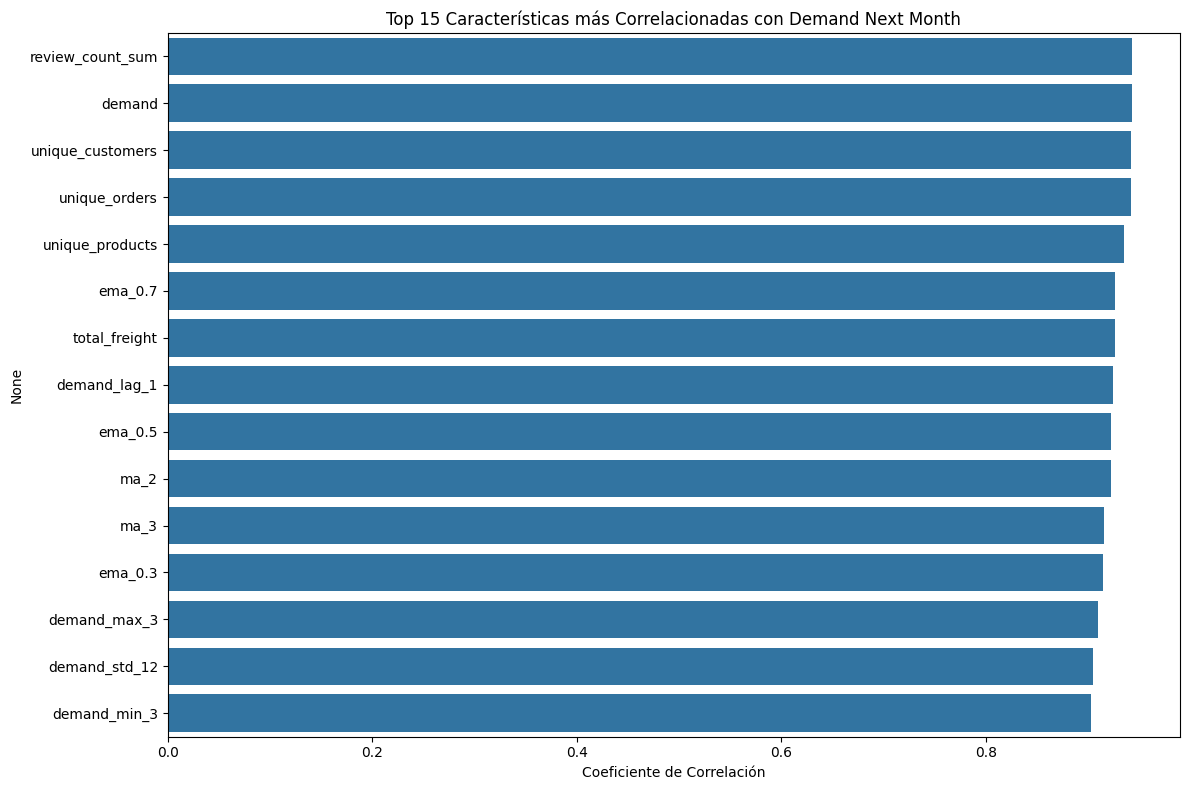

In [34]:
# Análisis de correlación con la variable objetivo
# Asumiendo que 'demand_next_month' es la variable objetivo
# Excluir columnas no numéricas del cálculo de correlación
target_corr = df.corr(numeric_only=True)['demand_next_month'].sort_values(ascending=False)
print("Correlación con demand_next_month:")
print(target_corr.head(90))
print("\nCorrelación con demand_next_month (menores):")
print(target_corr.tail(15))

# Visualizar correlaciones más importantes
plt.figure(figsize=(12, 8))
top_corr_features = target_corr.index[1:16]  # Excluyendo la correlación consigo misma
sns.barplot(x=target_corr.values[1:16], y=top_corr_features)
plt.title('Top 15 Características más Correlacionadas con Demand Next Month')
plt.xlabel('Coeficiente de Correlación')
plt.tight_layout()
plt.show()

In [26]:
df.shape

(1195, 175)

##Seleccionar la features mas relevantes

In [38]:
# Preparar datos para modelado
# Seleccionar características y variable objetivo
X = df.drop(['demand_next_month', 'order_month', 'date', 'month_year', 'product_category_name'], axis=1, errors='ignore')
y = df['demand_next_month']

# Manejar valores infinitos y NaN
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Modelo XGboost

Top 10 características importantes - XGBoost:
                    feature  importance
112                 ema_0.3    0.478671
0                    demand    0.192434
18         review_count_sum    0.136567
1           unique_products    0.017839
79            demand_lag_12    0.012501
2             unique_orders    0.009359
52               is_october    0.009042
108           demand_std_12    0.007975
160  category_median_demand    0.007317
102            demand_max_3    0.005903


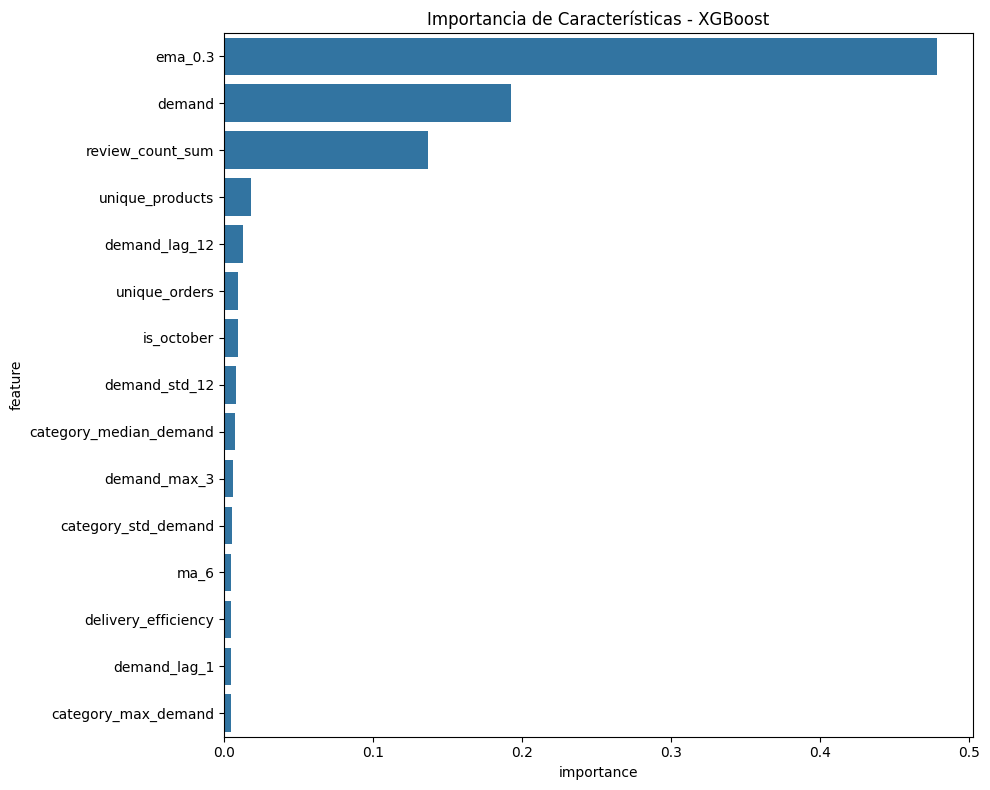

In [39]:
# 1. Modelo XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

# Importancia de características XGBoost
xgb_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 características importantes - XGBoost:")
print(xgb_importance.head(10))

plt.figure(figsize=(10, 8))
sns.barplot(data=xgb_importance.head(15), x='importance', y='feature')
plt.title('Importancia de Características - XGBoost')
plt.tight_layout()
plt.show()

## 2 Modelo LightGboost

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007576 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 28890
[LightGBM] [Info] Number of data points in the train set: 956, number of used features: 170
[LightGBM] [Info] Start training from score 89.940377
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

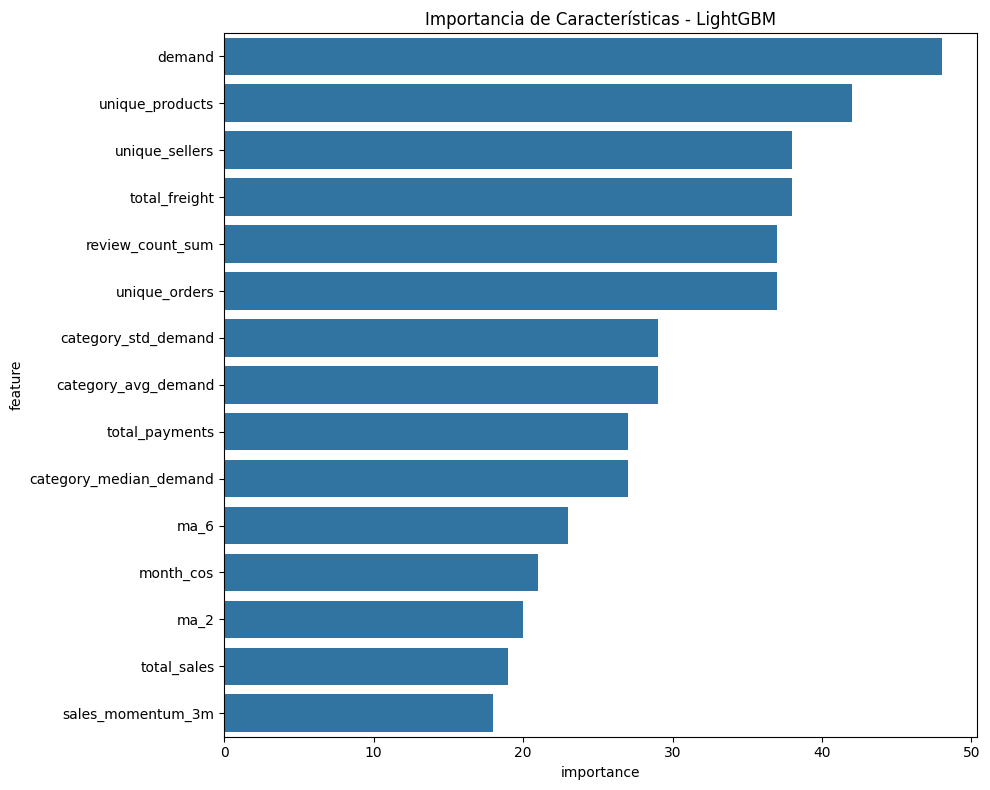

In [40]:
# 2. Modelo LightGBM
lgb_model = lgb.LGBMRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test)

# Importancia de características LightGBM
lgb_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 características importantes - LightGBM:")
print(lgb_importance.head(10))

plt.figure(figsize=(10, 8))
sns.barplot(data=lgb_importance.head(15), x='importance', y='feature')
plt.title('Importancia de Características - LightGBM')
plt.tight_layout()
plt.show()

# Modelo LSTM

In [41]:
# 3. Modelo LSTM
# Preparar datos para LSTM
X_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_test_lstm = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

# Construir modelo LSTM
lstm_model = Sequential([
    LSTM(64, activation='relu', input_shape=(1, X_train_scaled.shape[1]), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Entrenar modelo LSTM
history = lstm_model.fit(
    X_lstm, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

lstm_pred = lstm_model.predict(X_test_lstm).flatten()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 28985.8320 - mae: 83.8388 - val_loss: 45263.8008 - val_mae: 116.4899
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 24448.8203 - mae: 78.7541 - val_loss: 35713.9648 - val_mae: 104.7181
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 17873.4766 - mae: 67.3088 - val_loss: 13107.8975 - val_mae: 64.2807
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6132.6709 - mae: 40.4315 - val_loss: 4042.8899 - val_mae: 36.6198
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4706.4717 - mae: 38.2780 - val_loss: 3656.5107 - val_mae: 32.0616
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3188.8933 - mae: 28.3632 - val_loss: 2938.9473 - val_mae: 27.4062
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2022.9594 - mae: 22.5005 - val_loss: 2970.1033 - val_mae: 26.8659
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1812.1561 - mae: 21.0496 - val_loss: 2410.4124 - val_mae: 24.5807

## Evaluacion de los modelos

In [42]:
# Evaluación de modelos
def evaluate_model(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mse)

    metrics = {
        'Modelo': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape,
        'R²': r2
    }

    print(f"\n{name}:")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MAPE: {mape:.4f}")
    print(f"R²: {r2:.4f}")

    return metrics

# Evaluar todos los modelos
results = []
results.append(evaluate_model("XGBoost", y_test, xgb_pred))
results.append(evaluate_model("LightGBM", y_test, lgb_pred))
results.append(evaluate_model("LSTM", y_test, lstm_pred))

# Comparativa de resultados
results_df = pd.DataFrame(results)
print("\nComparativa de Modelos:")
print(results_df)


XGBoost:
MSE: 2004.0030
RMSE: 44.7661
MAE: 22.8352
MAPE: 0.6068
R²: 0.9154

LightGBM:
MSE: 1803.2120
RMSE: 42.4642
MAE: 21.7524
MAPE: 0.6066
R²: 0.9239

LSTM:
MSE: 1436.8903
RMSE: 37.9063
MAE: 19.6814
MAPE: 0.6010
R²: 0.9393

Comparativa de Modelos:
     Modelo          MSE       RMSE        MAE      MAPE        R²
0   XGBoost  2004.002985  44.766092  22.835190  0.606823  0.915372
1  LightGBM  1803.212037  42.464244  21.752426  0.606568  0.923851
2      LSTM  1436.890325  37.906336  19.681393  0.601043  0.939321


## Analisis de caracteristicas mas importantes

Top 15 características más importantes (combinado):
                    feature  avg_importance
0                    demand       24.096217
1           unique_products       21.008920
4            unique_sellers       19.000637
10            total_freight       19.000041
18         review_count_sum       18.568284
2             unique_orders       18.504680
159     category_std_demand       14.502634
158     category_avg_demand       14.501251
160  category_median_demand       13.503659
12           total_payments       13.500058
92                     ma_6       11.502411
36                month_cos       10.500527
84                     ma_2       10.000906
5               total_sales        9.500097
122       sales_momentum_3m        9.000335


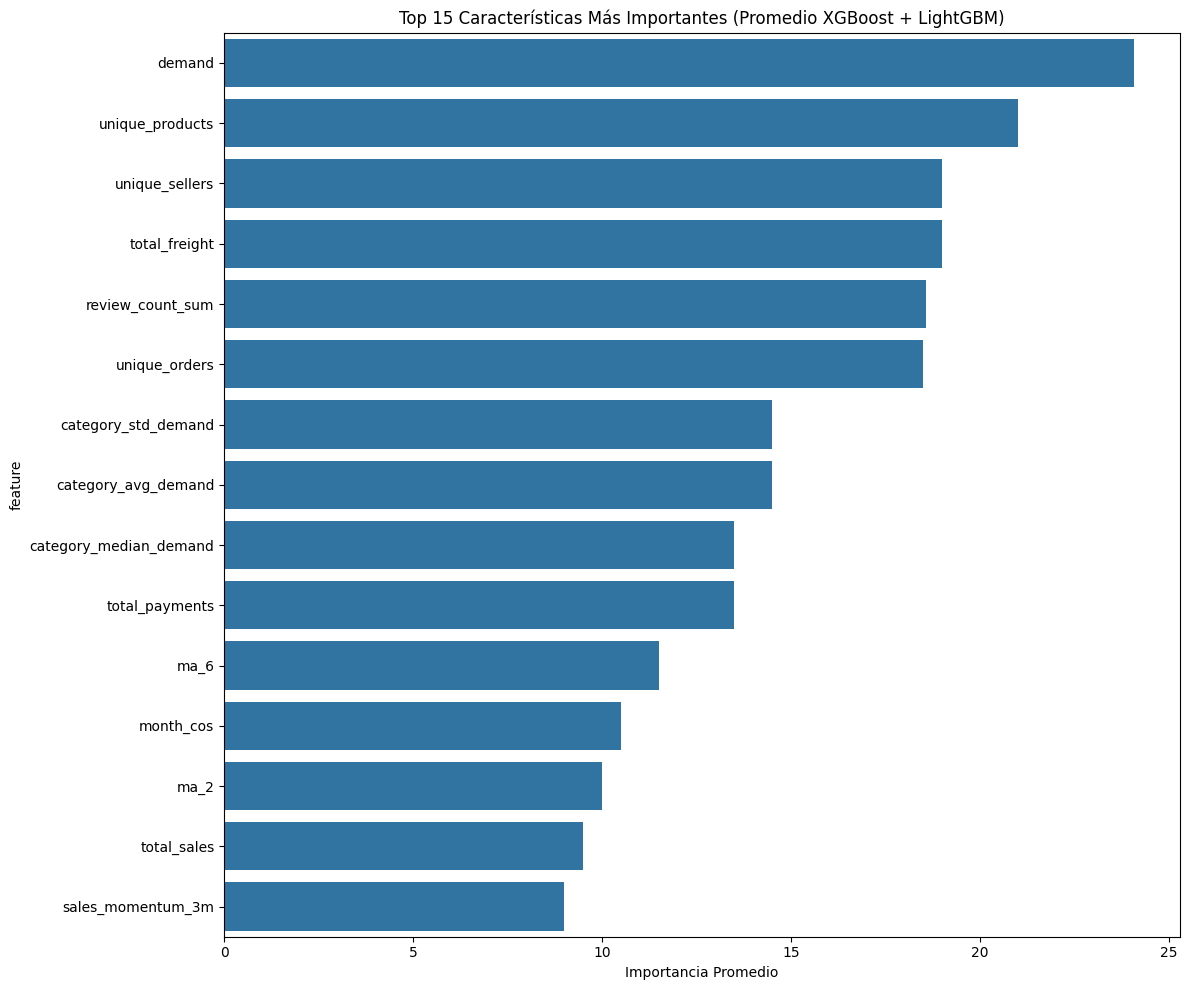

In [43]:
# Análisis de características más importantes consolidadas
feature_importance_combined = pd.DataFrame({
    'feature': X.columns,
    'xgb_importance': xgb_model.feature_importances_,
    'lgb_importance': lgb_model.feature_importances_
})

# Calcular importancia promedio
feature_importance_combined['avg_importance'] = (
    feature_importance_combined['xgb_importance'] +
    feature_importance_combined['lgb_importance']
) / 2

top_features_combined = feature_importance_combined.sort_values('avg_importance', ascending=False).head(15)

print("Top 15 características más importantes (combinado):")
print(top_features_combined[['feature', 'avg_importance']])

# Visualización comparativa
plt.figure(figsize=(12, 10))
sns.barplot(data=top_features_combined, x='avg_importance', y='feature')
plt.title('Top 15 Características Más Importantes (Promedio XGBoost + LightGBM)')
plt.xlabel('Importancia Promedio')
plt.tight_layout()
plt.show()

## Analisis especificos con las caracteristicas mas importantes

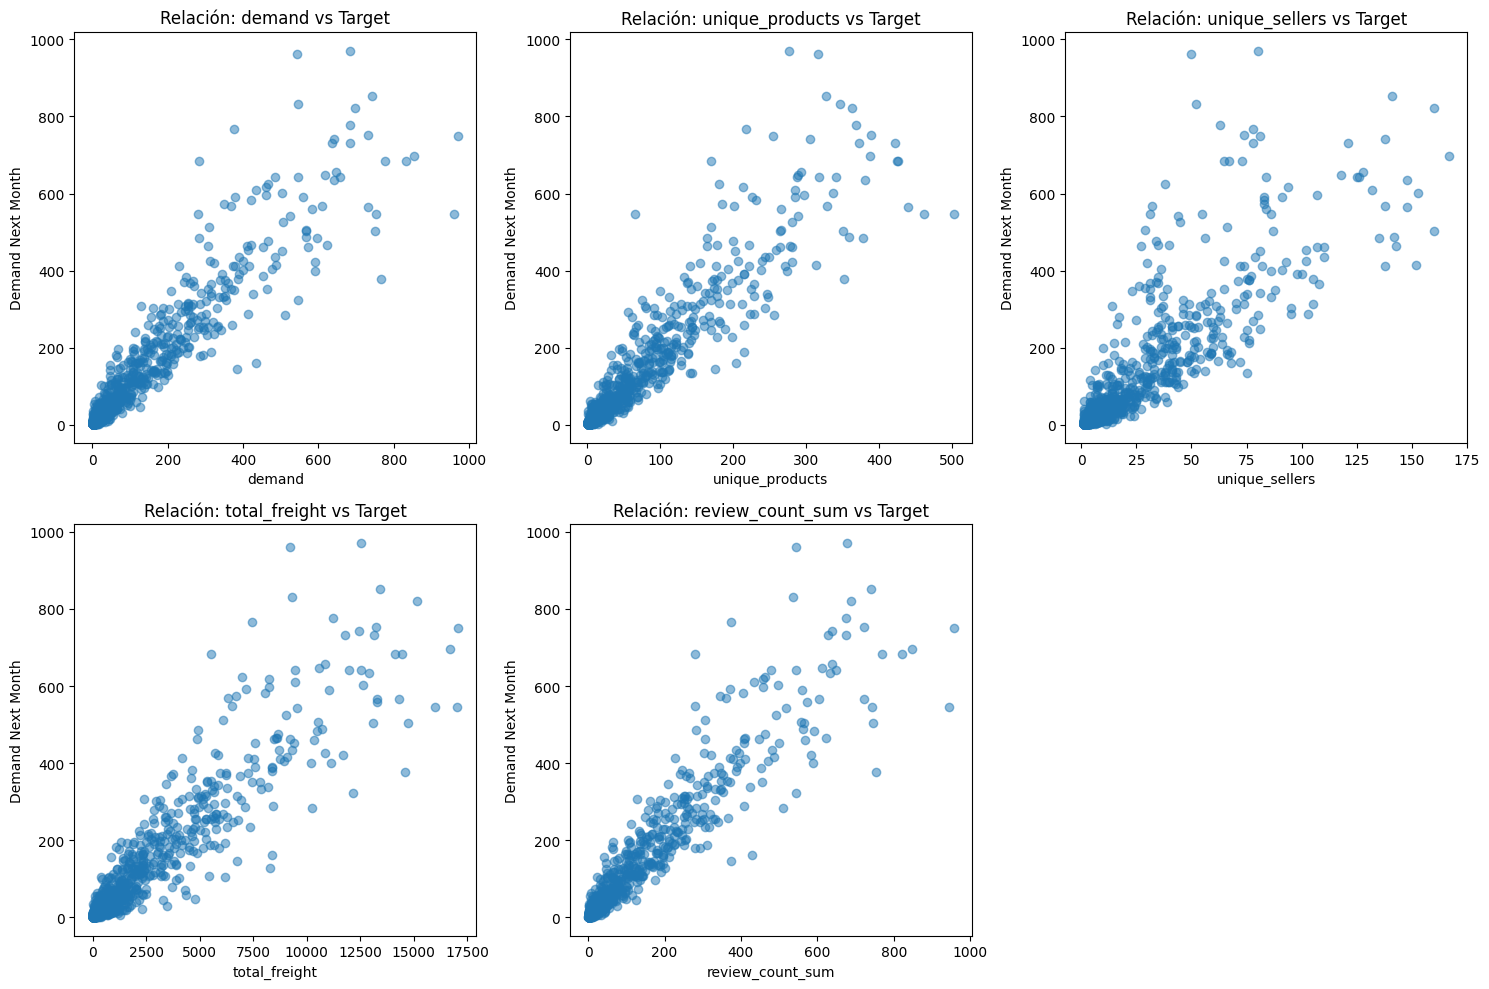

In [44]:
# Análisis de relaciones específicas con las características más importantes
top_5_features = top_features_combined['feature'].head(5).tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, feature in enumerate(top_5_features):
    if i < 6:
        axes[i].scatter(df[feature], df['demand_next_month'], alpha=0.5)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Demand Next Month')
        axes[i].set_title(f'Relación: {feature} vs Target')

# Ocultar ejes vacíos
for i in range(len(top_5_features), 6):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

## Cuadro comparativo de metricas

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Crear dataframe comparativo de métricas
comparison_df = pd.DataFrame({
    'Modelo': ['XGBoost', 'LightGBM', 'LSTM'],
    'MSE': [results[0]['MSE'], results[1]['MSE'], results[2]['MSE']],
    'RMSE': [results[0]['RMSE'], results[1]['RMSE'], results[2]['RMSE']],
    'MAE': [results[0]['MAE'], results[1]['MAE'], results[2]['MAE']],
    'MAPE': [results[0]['MAPE'], results[1]['MAPE'], results[2]['MAPE']],
    'R²': [results[0]['R²'], results[1]['R²'], results[2]['R²']]
})

print("═" * 80)
print("CUADRO COMPARATIVO DE MÉTRICAS - MODELOS DE PREDICCIÓN")
print("═" * 80)
print(comparison_df.round(4))
print("═" * 80)

# Identificar el mejor modelo para cada métrica
best_models = {}
metrics = ['MSE', 'RMSE', 'MAE', 'MAPE', 'R²']

for metric in metrics:
    if metric == 'R²':
        best_idx = comparison_df[metric].idxmax()
        best_value = comparison_df.loc[best_idx, metric]
        best_model = comparison_df.loc[best_idx, 'Modelo']
    else:
        best_idx = comparison_df[metric].idxmin()
        best_value = comparison_df.loc[best_idx, metric]
        best_model = comparison_df.loc[best_idx, 'Modelo']

    best_models[metric] = (best_model, best_value)

print("\nMEJORES MODELOS POR MÉTRICA:")
print("-" * 40)
for metric, (model, value) in best_models.items():
    if metric == 'R²':
        print(f"{metric}: {model} (valor: {value:.4f})")
    else:
        print(f"{metric}: {model} (valor: {value:.4f})")


════════════════════════════════════════════════════════════════════════════════
CUADRO COMPARATIVO DE MÉTRICAS - MODELOS DE PREDICCIÓN
════════════════════════════════════════════════════════════════════════════════
     Modelo        MSE     RMSE      MAE    MAPE      R²
0   XGBoost  2004.0030  44.7661  22.8352  0.6068  0.9154
1  LightGBM  1803.2120  42.4642  21.7524  0.6066  0.9239
2      LSTM  1436.8903  37.9063  19.6814  0.6010  0.9393
════════════════════════════════════════════════════════════════════════════════

MEJORES MODELOS POR MÉTRICA:
----------------------------------------
MSE: LSTM (valor: 1436.8903)
RMSE: LSTM (valor: 37.9063)
MAE: LSTM (valor: 19.6814)
MAPE: LSTM (valor: 0.6010)
R²: LSTM (valor: 0.9393)


## COMPARACION METRICAS MSE RMSE

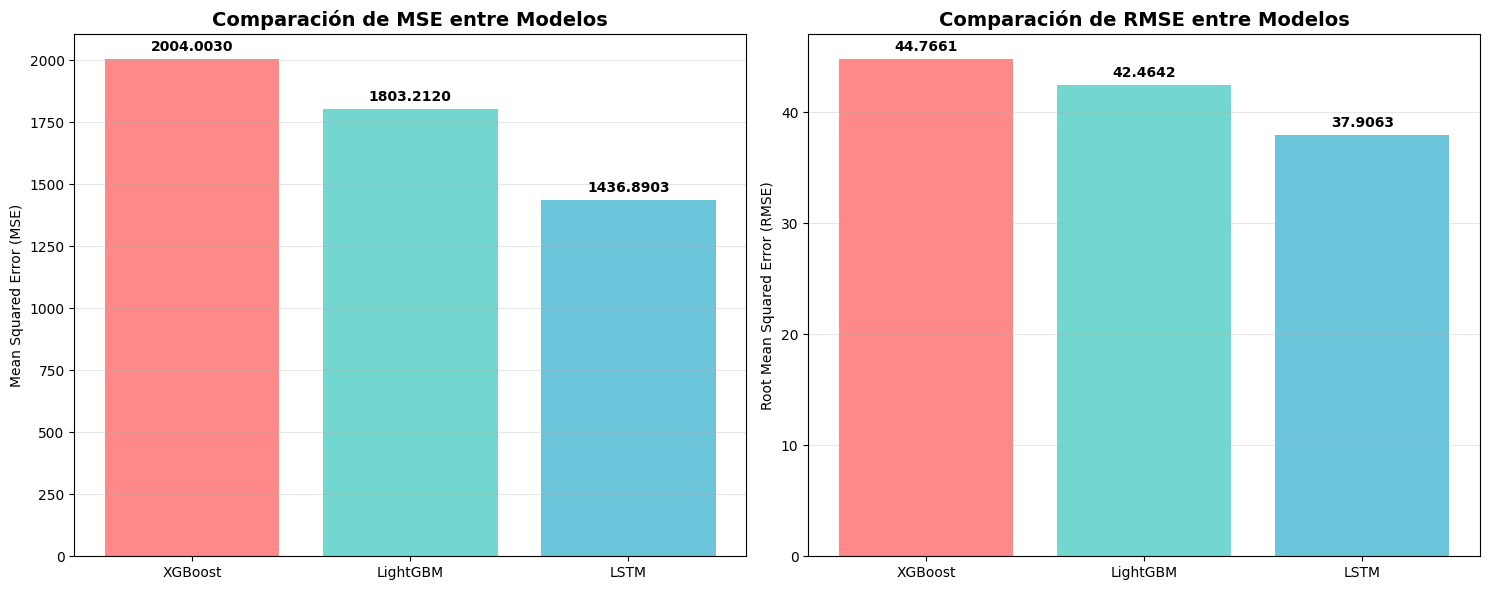

In [51]:
# Configuración de estilo para las gráficas
plt.style.use('default')
sns.set_palette("husl")

# 1. Gráfica de comparación de MSE y RMSE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# MSE
bars1 = ax1.bar(comparison_df['Modelo'], comparison_df['MSE'],
                color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)
ax1.set_title('Comparación de MSE entre Modelos', fontsize=14, fontweight='bold')
ax1.set_ylabel('Mean Squared Error (MSE)')
ax1.grid(axis='y', alpha=0.3)

# Añadir valores en las barras
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + max(comparison_df['MSE'])*0.01,
            f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

# RMSE
bars2 = ax2.bar(comparison_df['Modelo'], comparison_df['RMSE'],
                color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)
ax2.set_title('Comparación de RMSE entre Modelos', fontsize=14, fontweight='bold')
ax2.set_ylabel('Root Mean Squared Error (RMSE)')
ax2.grid(axis='y', alpha=0.3)

# Añadir valores en las barras
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + max(comparison_df['RMSE'])*0.01,
            f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## COMPARACION DE MAE Y MAPE

##

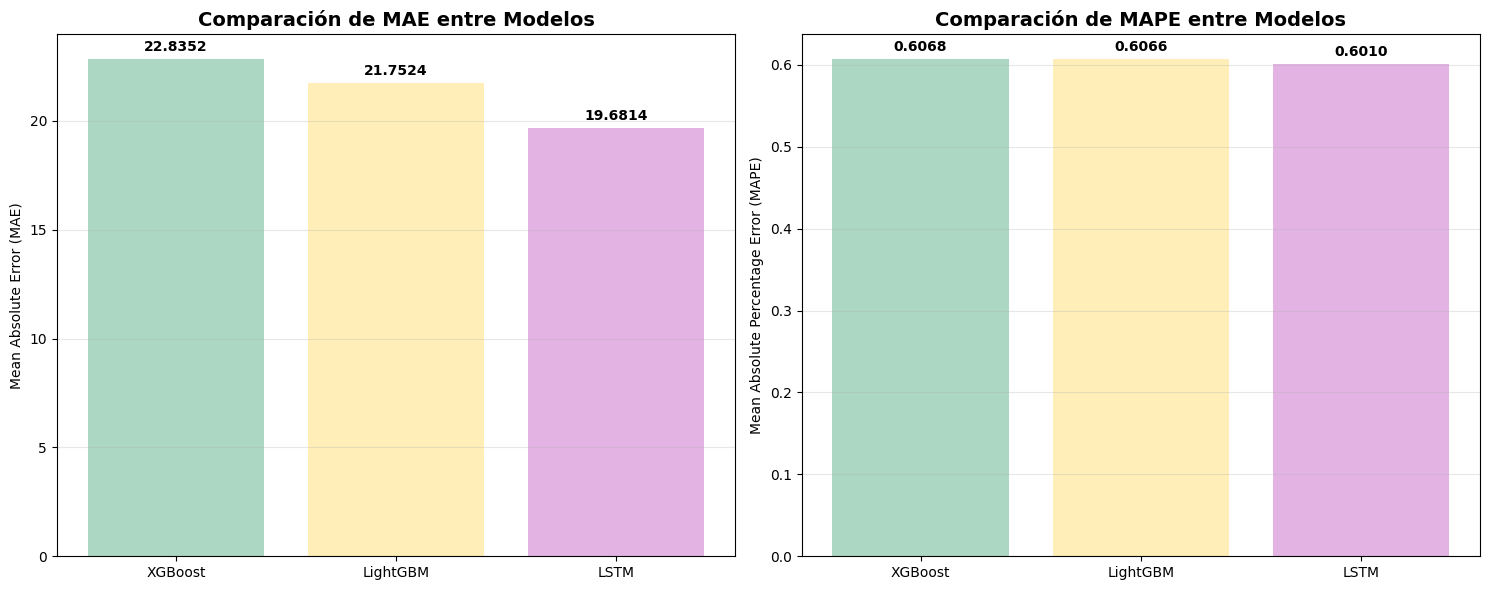

In [53]:

# 2. Gráfica de comparación de MAE y MAPE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# MAE
bars1 = ax1.bar(comparison_df['Modelo'], comparison_df['MAE'],
                color=['#96CEB4', '#FFEAA7', '#DDA0DD'], alpha=0.8)
ax1.set_title('Comparación de MAE entre Modelos', fontsize=14, fontweight='bold')
ax1.set_ylabel('Mean Absolute Error (MAE)')
ax1.grid(axis='y', alpha=0.3)

# Añadir valores en las barras
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + max(comparison_df['MAE'])*0.01,
            f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

# MAPE
bars2 = ax2.bar(comparison_df['Modelo'], comparison_df['MAPE'],
                color=['#96CEB4', '#FFEAA7', '#DDA0DD'], alpha=0.8)
ax2.set_title('Comparación de MAPE entre Modelos', fontsize=14, fontweight='bold')
ax2.set_ylabel('Mean Absolute Percentage Error (MAPE)')
ax2.grid(axis='y', alpha=0.3)

# Añadir valores en las barras
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + max(comparison_df['MAPE'])*0.01,
            f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## GRAFICA R2

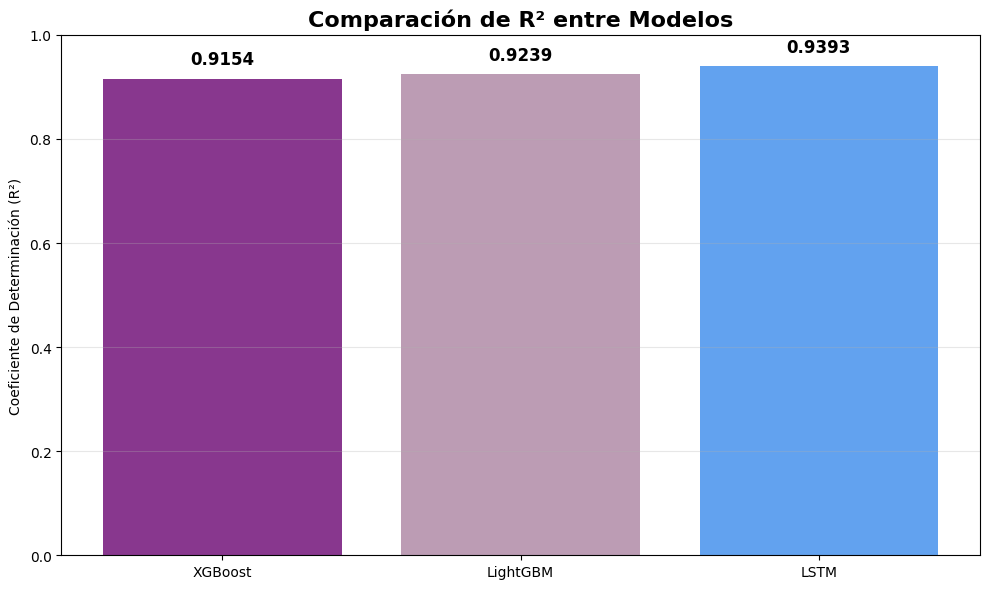

In [54]:
# 3. Gráfica de R²
plt.figure(figsize=(10, 6))
bars = plt.bar(comparison_df['Modelo'], comparison_df['R²'],
               color=['#6A0572', '#AB83A1', '#3B8BEB'], alpha=0.8)
plt.title('Comparación de R² entre Modelos', fontsize=16, fontweight='bold')
plt.ylabel('Coeficiente de Determinación (R²)')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

# Añadir valores en las barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

##HEAT NAP DE METRICAS NORMALIZADASS

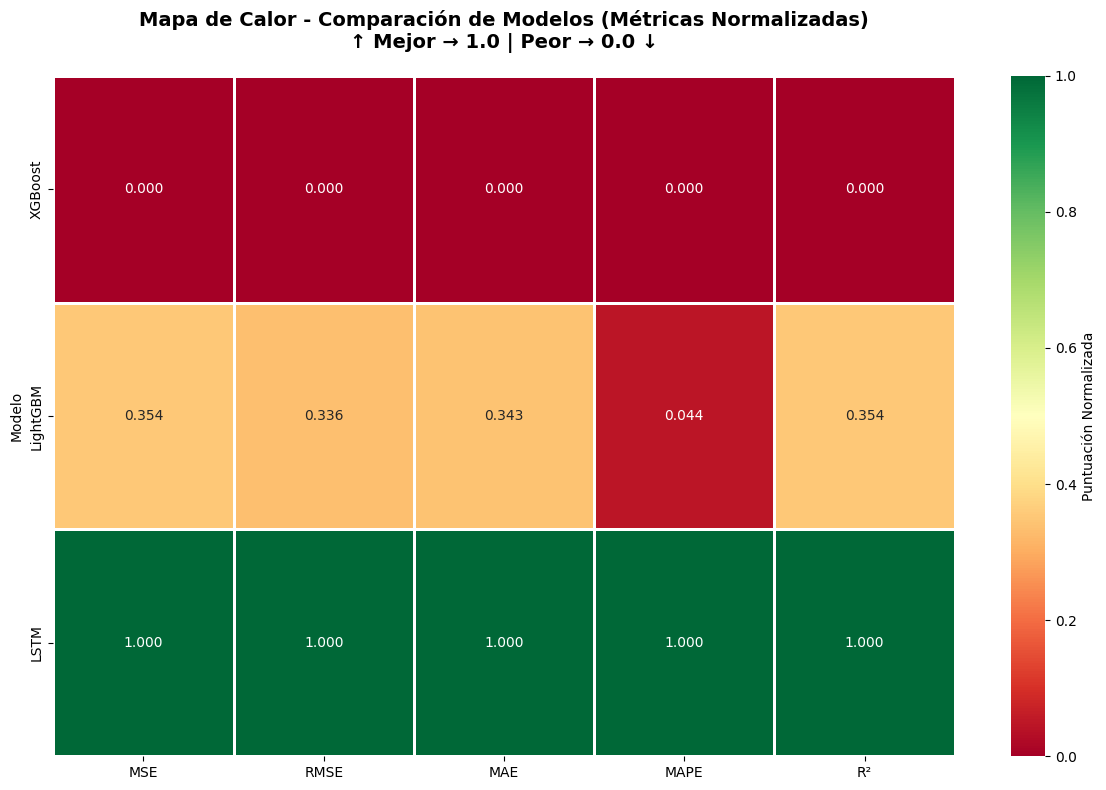

In [55]:
# 4. Heatmap de métricas normalizadas (para mejor visualización)
# Normalizar las métricas (excepto R²)
metrics_to_normalize = ['MSE', 'RMSE', 'MAE', 'MAPE']
normalized_df = comparison_df.copy()

for metric in metrics_to_normalize:
    # Para estas métricas, menor es mejor, así que normalizamos inversamente
    min_val = comparison_df[metric].min()
    max_val = comparison_df[metric].max()
    normalized_df[metric] = 1 - (comparison_df[metric] - min_val) / (max_val - min_val)

# Para R², mayor es mejor, normalización directa
min_r2 = comparison_df['R²'].min()
max_r2 = comparison_df['R²'].max()
normalized_df['R²'] = (comparison_df['R²'] - min_r2) / (max_r2 - min_r2)

# Heatmap
plt.figure(figsize=(12, 8))
heatmap_data = normalized_df.set_index('Modelo')[['MSE', 'RMSE', 'MAE', 'MAPE', 'R²']]
sns.heatmap(heatmap_data, annot=True, cmap='RdYlGn', center=0.5,
           fmt='.3f', linewidths=1, cbar_kws={'label': 'Puntuación Normalizada'})
plt.title('Mapa de Calor - Comparación de Modelos (Métricas Normalizadas)\n↑ Mejor → 1.0 | Peor → 0.0 ↓',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## Comparacion multidimensional

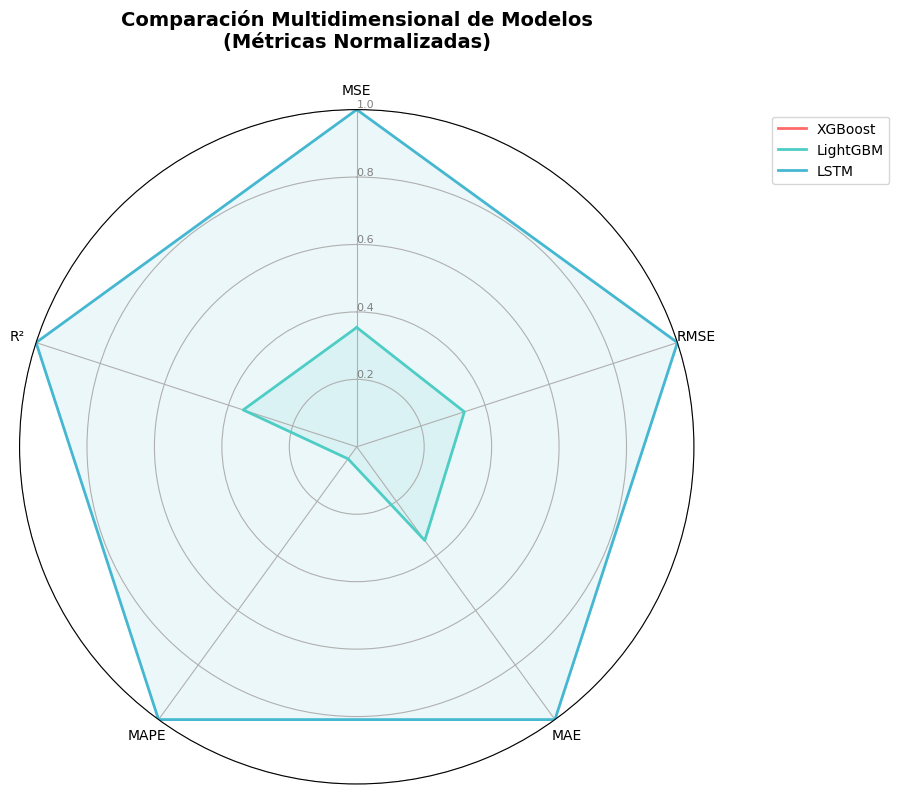

In [56]:
# 5. Gráfica radial (spider chart) para comparación multidimensional
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, polar=True)

# Métricas para el radar chart (usamos las normalizadas)
categories = ['MSE', 'RMSE', 'MAE', 'MAPE', 'R²']
N = len(categories)

# Ángulos para cada categoría
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Completar el círculo

# Configuración del gráfico radial
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories)

# Añadir marcas de valores
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=8)
plt.ylim(0, 1)

# Colores para cada modelo
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# Plot para cada modelo
for i, modelo in enumerate(normalized_df['Modelo']):
    values = normalized_df.loc[normalized_df['Modelo'] == modelo, categories].values[0].tolist()
    values += values[:1]  # Completar el círculo

    ax.plot(angles, values, linewidth=2, linestyle='solid', label=modelo, color=colors[i])
    ax.fill(angles, values, alpha=0.1, color=colors[i])

plt.title('Comparación Multidimensional de Modelos\n(Métricas Normalizadas)',
          size=14, fontweight='bold', y=1.08)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.show()

## Prediccion Vs valores reales

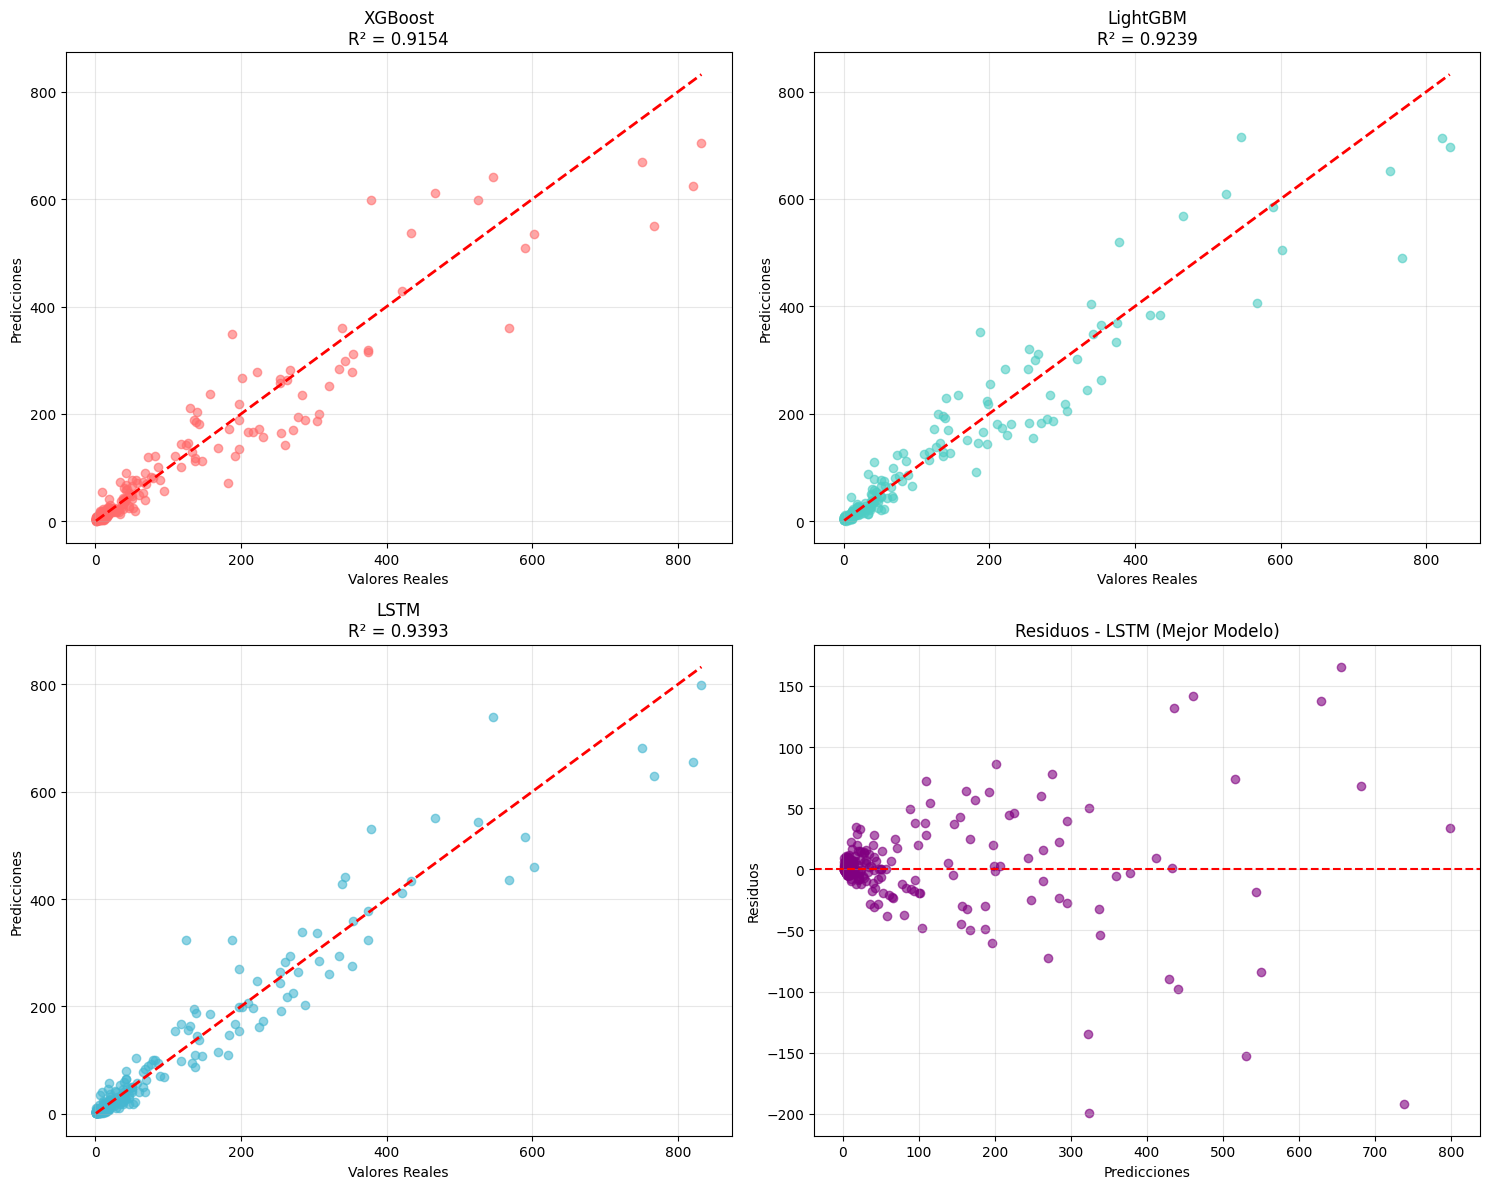

In [57]:
# 6. Gráfica de predicciones vs valores reales
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

model_predictions = {
    'XGBoost': xgb_pred,
    'LightGBM': lgb_pred,
    'LSTM': lstm_pred
}

for i, (model_name, predictions) in enumerate(model_predictions.items()):
    if i < 4:  # Asegurar que no excedamos el número de subplots
        axes[i].scatter(y_test, predictions, alpha=0.6, color=colors[i])
        axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
        axes[i].set_xlabel('Valores Reales')
        axes[i].set_ylabel('Predicciones')
        axes[i].set_title(f'{model_name}\nR² = {comparison_df.loc[comparison_df["Modelo"]==model_name, "R²"].values[0]:.4f}')
        axes[i].grid(True, alpha=0.3)

# Añadir gráfica de residuos para el mejor modelo según R²
best_model_name = best_models['R²'][0]
if best_model_name == 'XGBoost':
    best_predictions = xgb_pred
elif best_model_name == 'LightGBM':
    best_predictions = lgb_pred
else:
    best_predictions = lstm_pred

residuals = y_test - best_predictions
axes[3].scatter(best_predictions, residuals, alpha=0.6, color='purple')
axes[3].axhline(y=0, color='red', linestyle='--')
axes[3].set_xlabel('Predicciones')
axes[3].set_ylabel('Residuos')
axes[3].set_title(f'Residuos - {best_model_name} (Mejor Modelo)')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Resumen ejecutivo de resultados

In [58]:
# 7. Resumen ejecutivo de resultados
print("═" * 80)
print("RESUMEN EJECUTIVO - COMPARACIÓN DE MODELOS")
print("═" * 80)

# Determinar el mejor modelo general
# Puntuación basada en ranking de métricas
model_scores = {}

for modelo in comparison_df['Modelo']:
    score = 0
    model_data = comparison_df[comparison_df['Modelo'] == modelo]

    # Para métricas donde menor es mejor
    for metric in ['MSE', 'RMSE', 'MAE', 'MAPE']:
        ranking = (comparison_df[metric] <= model_data[metric].values[0]).sum()
        score += (4 - ranking + 1)  # Puntos inversos al ranking

    # Para R² (mayor es mejor)
    r2_ranking = (comparison_df['R²'] >= model_data['R²'].values[0]).sum()
    score += r2_ranking

    model_scores[modelo] = score

best_overall = max(model_scores, key=model_scores.get)

print(f"\n🏆 MEJOR MODELO GENERAL: {best_overall}")
print(f"Puntuación total: {model_scores[best_overall]} puntos")

print(f"\n📊 DESEMPEÑO POR MÉTRICA CLAVE:")
print(f"• MAPE (Error Porcentual): {comparison_df.loc[comparison_df['Modelo']==best_overall, 'MAPE'].values[0]:.4f}")
print(f"• R² (Explicación de Varianza): {comparison_df.loc[comparison_df['Modelo']==best_overall, 'R²'].values[0]:.4f}")

print(f"\n💡 RECOMENDACIONES:")
if best_overall in ['XGBoost', 'LightGBM']:
    print("• El modelo de árboles es más interpretable y rápido")
    print("• Ideal para producción por eficiencia computacional")
else:
    print("• El modelo LSTM captura patrones temporales complejos")
    print("• Considerar mayor cantidad de datos para mejorar desempeño")

print(f"\n🎯 PRÓXIMOS PASOS SUGERIDOS:")
print("1. Optimización de hiperparámetros del modelo ganador")
print("2. Validación cruzada temporal")
print("3. Ensemble del top 2 modelos")
print("4. Análisis de errores por categoría de producto")
print("═" * 80)

════════════════════════════════════════════════════════════════════════════════
RESUMEN EJECUTIVO - COMPARACIÓN DE MODELOS
════════════════════════════════════════════════════════════════════════════════

🏆 MEJOR MODELO GENERAL: LSTM
Puntuación total: 17 puntos

📊 DESEMPEÑO POR MÉTRICA CLAVE:
• MAPE (Error Porcentual): 0.6010
• R² (Explicación de Varianza): 0.9393

💡 RECOMENDACIONES:
• El modelo LSTM captura patrones temporales complejos
• Considerar mayor cantidad de datos para mejorar desempeño

🎯 PRÓXIMOS PASOS SUGERIDOS:
1. Optimización de hiperparámetros del modelo ganador
2. Validación cruzada temporal
3. Ensemble del top 2 modelos
4. Análisis de errores por categoría de producto
════════════════════════════════════════════════════════════════════════════════
